# 1. Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# 2. Sold Data 

In [2]:
df_sold = pd.read_csv("sold_residential.csv")


C:\Users\junki\AppData\Local\Temp\ipykernel_5528\3153523404.py:1: DtypeWarning: Columns (0: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sold = pd.read_csv("sold_residential.csv")


In [3]:
# show number of features and rows
print(df_sold.shape)

# number of rows for count dropped rows later
row_df = df_sold.shape[0]

df_sold.head()

(430075, 61)


,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,...,Stories,HighSchool,Levels,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,MiddleOrJuniorSchoolDistrict,BuyerAgencyCompensationType,BuyerAgencyCompensation
0,NaN,True,NaN,NaN,True,598000.0,1048490409,2024-01-01,555000.0,Shelli,...,1.0,NaN,One,False,2.0,Riverside Unified,92504,NaN,NaN,NaN
1,Laminate,False,NaN,NaN,False,915000.0,1046722825,2024-01-01,915000.0,Esperanza,...,2.0,NaN,Two,NaN,2.0,Moorpark Unified,93021,NaN,NaN,NaN
2,Wood,True,NaN,NaN,False,184500.0,1048590625,2024-01-01,186500.0,Nathan,...,1.0,NaN,One,False,0.0,NaN,92026,NaN,NaN,NaN
3,NaN,True,NaN,NaN,False,1600000.0,1054052014,2024-01-01,1600000.0,Joseph,...,2.0,NaN,Two,False,2.0,NaN,92054,NaN,NaN,NaN
4,"Laminate,Tile",False,NaN,NaN,False,535000.0,1046369026,2024-01-01,535000.0,Gustavo,...,1.0,NaN,One,False,2.0,Rialto Unified,92376,NaN,NaN,NaN


We have 430075 properties in California with 61 features of the real estate market features.

In [4]:
pd.set_option("display.max_rows", None)

Let's check missing values in sold dataset. First, we will identify and flag on features that have more than 90% of missing values.

In [5]:
# check all features for percentage of missing values
missing_ratio = df_sold.isna().sum() / df_sold.shape[0]
print(missing_ratio.sort_values(ascending=False))

# call features that contain more than 90% of missing values
missing_high = missing_ratio[missing_ratio>=0.9]
print()
print("Missing more than 90%")
print(missing_high.sort_values(ascending=False))

TaxAnnualAmount                 1.000000
FireplacesTotal                 1.000000
MiddleOrJuniorSchoolDistrict    1.000000
ElementarySchoolDistrict        1.000000
TaxYear                         1.000000
BusinessType                    1.000000
WaterfrontYN                    0.999370
BasementYN                      0.980399
BuilderName                     0.951041
BuyerAgencyCompensation         0.892802
BuyerAgencyCompensationType     0.892777
ElementarySchool                0.866986
MiddleOrJuniorSchool            0.866100
HighSchool                      0.826095
SubdivisionName                 0.627509
Flooring                        0.358775
HighSchoolDistrict              0.275336
Stories                         0.153648
AttachedGarageYN                0.152792
MLSAreaMajor                    0.134191
Levels                          0.096002
PoolPrivateYN                   0.085897
ViewYN                          0.085504
LotSizeAcres                    0.078198
NewConstructionY

The missning values more than 90% are **FireplacesTotal**, **BusinessType**, **TaxAnnualAmount**, **ElementarySchoolDistrict**,**TaxYear**,**MiddleOrJuniorSchoolDistrict**,**WaterfrontYN**,**BasementYN**, and **BuilderName**. We will drop those missing values and those are not strongly relevant from identifying housing market features.

In [6]:
# drop features over 90% missing values
df_sold = df_sold.drop(columns = missing_high.index)

(df_sold.isna().sum() / df_sold.shape[0]) >= 0.9

Flooring                       False
ViewYN                         False
PoolPrivateYN                  False
OriginalListPrice              False
ListingKey                     False
CloseDate                      False
ClosePrice                     False
ListAgentFirstName             False
ListAgentLastName              False
Latitude                       False
Longitude                      False
UnparsedAddress                False
PropertyType                   False
LivingArea                     False
ListPrice                      False
DaysOnMarket                   False
ListOfficeName                 False
BuyerOfficeName                False
ListAgentFullName              False
BuyerAgentMlsId                False
BuyerAgentFirstName            False
BuyerAgentLastName             False
ListingKeyNumeric              False
MLSAreaMajor                   False
CountyOrParish                 False
MlsStatus                      False
ElementarySchool               False
A

In [7]:
# call features have missing values between 60% to 90%
missing_mid = missing_ratio[(missing_ratio>=0.6)&(missing_ratio<0.9)]
missing_mid.sort_values(ascending=False)

BuyerAgencyCompensation        0.892802
BuyerAgencyCompensationType    0.892777
ElementarySchool               0.866986
MiddleOrJuniorSchool           0.866100
HighSchool                     0.826095
SubdivisionName                0.627509
dtype: float64

These are the features that are not consistently reported across the dataset, because more than half of records are missing. For this analysis, we identified as high missing features 60% to 90% that we avoid using them for major conclusions unless we specifically focus on the subset of records.



**BuyerAgencyCompensation** and **BuyerAgencyCompensationType** are missing high because buyers agent compensation became more complicated after 2024 National Association of Realtors (NAR) settlement changes. The real estate primer says buyer agent compensation is not negociated separetly rather than automatically offered through the Multiple Listing Service (MLS).

NAR  refers to major 2024 rule changes after lawsuits about real estate commissions. Before the settlement, many MLS systems showed how much compensation the seller/listing broker was offering to the buyer’s agent. After the settlement changes, offers of compensation are no longer allowed on MLS platforms, although sellers can still offer compensation outside the MLS through negotiation.

The school information is highly missing probably because is often optional, inconsistent, or location-dependent in MLS data. A property can be near one school but assigned to another school district or boundary.

SubdivisionName is also often optional. It is more common in planned communities, newer developments, HOA neighborhoods, or tract housing. But many older homes, rural properties, or urban properties may not have a formal subdivision name

In [8]:
# call features have missing values between 30% to 60%
missing_mid_low = missing_ratio[(missing_ratio>=0.3)&(missing_ratio<0.6)]
missing_mid_low.sort_values(ascending=False)

Flooring    0.358775
dtype: float64

Flooring feature had moderate missing values of 35.88% that one-third of records did not report flooring information, and we should interpret with caution.


## 1) Explicit Implicit Missing Values
Let's identify if there is implicit missing values.

In [9]:
# Listing data types
df_sold.dtypes

Flooring                           str
ViewYN                          object
PoolPrivateYN                   object
OriginalListPrice              float64
ListingKey                       int64
CloseDate                          str
ClosePrice                     float64
ListAgentFirstName                 str
ListAgentLastName                  str
Latitude                       float64
Longitude                      float64
UnparsedAddress                    str
PropertyType                       str
LivingArea                     float64
ListPrice                      float64
DaysOnMarket                     int64
ListOfficeName                     str
BuyerOfficeName                    str
ListAgentFullName                  str
BuyerAgentMlsId                    str
BuyerAgentFirstName                str
BuyerAgentLastName                 str
ListingKeyNumeric                int64
MLSAreaMajor                       str
CountyOrParish                     str
MlsStatus                

Let's divide features into each data types

In [10]:
# divide features into each data types
numeric = [
    'OriginalListPrice',
    'ClosePrice',
    'Latitude',
    'Longitude',
    'LivingArea',
    'ListPrice',
    'ParkingTotal',
    'YearBuilt',
    'BathroomsTotalInteger',
    'Stories',
    'GarageSpaces',
    'LotSizeAcres',
    'BuyerAgencyCompensation'
]

discrete = [
    'DaysOnMarket',
    'BedroomsTotal'
]

categorical = [
    'Flooring',
    'ViewYN',
    'PoolPrivateYN',
    'ListAgentFirstName',
    'ListAgentLastName',
    'UnparsedAddress',
    'PropertyType',
    'ListOfficeName',
    'BuyerOfficeName',
    'ListAgentFullName',
    'BuyerAgentMlsId',
    'BuyerAgentFirstName',
    'BuyerAgentLastName',
    'MLSAreaMajor',
    'CountyOrParish',
    'MlsStatus',
    'ElementarySchool',
    'AttachedGarageYN',
    'PropertySubType',
    'SubdivisionName',
    'City',
    'StateOrProvince',
    'MiddleOrJuniorSchool',
    'FireplaceYN',
    'HighSchool',
    'Levels',
    'NewConstructionYN',
    'HighSchoolDistrict',
    'PostalCode',
    'BuyerAgencyCompensationType'
]

date_feature = [
    'CloseDate',
    'ContractStatusChangeDate',
    'PurchaseContractDate',
    'ListingContractDate'
]

id_feature = [
    'ListingKey',
    'ListingKeyNumeric',
    'ListingId'
]

Let's identify the numeric explicit and implicit missing values.

In [11]:
# numeric data types
df_sold[numeric+discrete].dtypes

OriginalListPrice          float64
ClosePrice                 float64
Latitude                   float64
Longitude                  float64
LivingArea                 float64
ListPrice                  float64
ParkingTotal               float64
YearBuilt                  float64
BathroomsTotalInteger      float64
Stories                    float64
GarageSpaces               float64
LotSizeAcres               float64
BuyerAgencyCompensation    float64
DaysOnMarket                 int64
BedroomsTotal              float64
dtype: object

All numeric features show float64 or int64 that there is no implicit missing values.

In [12]:
# percentage of explicit missing values
df_sold[numeric+discrete].isna().sum()*100/df_sold.shape[0]

OriginalListPrice           0.183456
ClosePrice                  0.000233
Latitude                    3.738883
Longitude                   3.738883
LivingArea                  0.056967
ListPrice                   0.000000
ParkingTotal                0.099052
YearBuilt                   0.088822
BathroomsTotalInteger       0.016276
Stories                    15.364762
GarageSpaces                4.298320
LotSizeAcres                7.819799
BuyerAgencyCompensation    89.280242
DaysOnMarket                0.000000
BedroomsTotal               0.002790
dtype: float64

Excep the BuyersAgencyCompensation, numeric features have minimal percentage of explicit missing values.

Let's identify the date features.

In [13]:
# date feature data type
df_sold[date_feature].dtypes

CloseDate                   str
ContractStatusChangeDate    str
PurchaseContractDate        str
ListingContractDate         str
dtype: object

In [14]:
# list of implicit missing values
implicit_missing_values = [
    '',
    ' ',
    'Unknown',
    'unknown',
    'UNKNOWN',
    'N/A',
    'NA',
    'na',
    'None',
    'none',
    'NULL',
    'null',
    '--',
    '-',
    'Missing',
    'missing'
]

# scan implicit missing values match with date features
for i in date_feature:
    col = df_sold[i]
    implicit = col[col.isin(implicit_missing_values)].unique().tolist()
    print(f"{i} feature of values")
    print(implicit)
    print()

CloseDate feature of values
[]

ContractStatusChangeDate feature of values
[]

PurchaseContractDate feature of values
[]

ListingContractDate feature of values
[]



There is no implicit missing values in date features.

In [15]:
# percentage of expllicit missing value for date features.
df_sold[date_feature].isna().sum()/df_sold.shape[0]

CloseDate                   0.000000
ContractStatusChangeDate    0.001370
PurchaseContractDate        0.000458
ListingContractDate         0.000002
dtype: float64

However, there are explicit missing values less than 1%

Let's identify the listing key features.

In [16]:
# show listing key features
df_sold[id_feature].dtypes

ListingKey           int64
ListingKeyNumeric    int64
ListingId              str
dtype: object

In [17]:
# scan implicit missing value in listing features
for i in id_feature:
    col = df_sold[i]
    implicit = col[col.isin(implicit_missing_values)].unique().tolist()
    print(f"{i} feature of values")
    print(implicit)
    print()

ListingKey feature of values
[]

ListingKeyNumeric feature of values
[]

ListingId feature of values
[]



There is no implicit missing values in listing key features.

In [18]:
# percentage explicit missing values
df_sold[id_feature].isna().sum()/df_sold.shape[0]

ListingKey           0.0
ListingKeyNumeric    0.0
ListingId            0.0
dtype: float64

There is no explicit missing values as well. 

Let's identify the categorical features.

In [19]:
# list data types for categorical
df_sold[categorical].dtypes

Flooring                          str
ViewYN                         object
PoolPrivateYN                  object
ListAgentFirstName                str
ListAgentLastName                 str
UnparsedAddress                   str
PropertyType                      str
ListOfficeName                    str
BuyerOfficeName                   str
ListAgentFullName                 str
BuyerAgentMlsId                   str
BuyerAgentFirstName               str
BuyerAgentLastName                str
MLSAreaMajor                      str
CountyOrParish                    str
MlsStatus                         str
ElementarySchool                  str
AttachedGarageYN               object
PropertySubType                   str
SubdivisionName                   str
City                              str
StateOrProvince                   str
MiddleOrJuniorSchool              str
FireplaceYN                    object
HighSchool                        str
Levels                            str
NewConstruct

In [20]:
# scan implicit missing values for categorical

for i in categorical:
    col = df_sold[i]
    implicit = col[col.isin(implicit_missing_values)].unique().tolist()
    print(f"{i} feature of values")
    print(implicit)
    print()

Flooring feature of values
[]

ViewYN feature of values
[]

PoolPrivateYN feature of values
[]

ListAgentFirstName feature of values
['-']

ListAgentLastName feature of values
[]

UnparsedAddress feature of values
[]

PropertyType feature of values
[]

ListOfficeName feature of values
[]

BuyerOfficeName feature of values
['UNKNOWN']

ListAgentFullName feature of values
[]

BuyerAgentMlsId feature of values
['none']

BuyerAgentFirstName feature of values
['Unknown', '-', 'none']

BuyerAgentLastName feature of values
['UNKNOWN', '-', 'none']

MLSAreaMajor feature of values
[]

CountyOrParish feature of values
[]

MlsStatus feature of values
[]

ElementarySchool feature of values
['Unknown']

AttachedGarageYN feature of values
[]

PropertySubType feature of values
[]

SubdivisionName feature of values
['none', 'Unknown', 'unknown', 'UNKNOWN', '-', 'na']

City feature of values
['Unknown']

StateOrProvince feature of values
[]

MiddleOrJuniorSchool feature of values
[]

FireplaceYN featur

There are couple implicit missing values in **BuyeerOfficeName**, **BuyerAgentMlsId**, **BuyerAgentFirstName**, **BuyerAgentLastName**, **ElementarySchool**, **SubdivisionName**, **City**, and **HighSchool**. 

In [21]:
df_sold[categorical].isna().sum() * 100 / df_sold.shape[0]

Flooring                       35.877463
ViewYN                          8.550369
PoolPrivateYN                   8.589665
ListAgentFirstName              0.744521
ListAgentLastName               0.009301
UnparsedAddress                 0.098122
PropertyType                    0.000000
ListOfficeName                  0.000000
BuyerOfficeName                 1.615765
ListAgentFullName               0.021857
BuyerAgentMlsId                 0.127885
BuyerAgentFirstName             0.478056
BuyerAgentLastName              0.040923
MLSAreaMajor                   13.419055
CountyOrParish                  0.000000
MlsStatus                       0.000000
ElementarySchool               86.698599
AttachedGarageYN               15.279195
PropertySubType                 0.193687
SubdivisionName                62.750916
City                            0.073243
StateOrProvince                 0.000000
MiddleOrJuniorSchool           86.610010
FireplaceYN                     0.080684
HighSchool      

Except **CountyOrParish**, **MlsStatus**, **ListOfficeName**, **PropertyType**, and **StateOrProvince**, other categorical features contain explicit missing values.

# Explanatory Data Analysis

We will explore features of housing market attributes flag invalid values and handling missing value values with filtering out those values into **df_sold_cleaned**. Then, identified flagged potential outliers using business and statistical rule, and filter out into **df_sold_cleaned_eda**.

## 1. Close Price

We will explore the close price considering mainstream of the close price in California. Let's check if there is invalid sold price and exclude the explicit missing values of 0.0002%.

In [22]:
# identify explicit missing values for close price
print("Number of property of sold price with negative (invalid) value:", df_sold[df_sold["ClosePrice"]<0].shape[0])
print("Number of property that is missing or 0 value:", df_sold[df_sold["ClosePrice"]==0].shape[0])

Number of property of sold price with negative (invalid) value: 0
Number of property that is missing or 0 value: 1


There is no negative value but there is one property that is sold 0 dollars.

In [23]:
df_sold[df_sold["ClosePrice"]==0]

,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,...,FireplaceYN,Stories,HighSchool,Levels,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerAgencyCompensationType,BuyerAgencyCompensation
285193,"Carpet,Laminate",True,False,1350000.0,1117019091,2025-07-30,0.0,Claudia,Lee,34.096368,...,True,NaN,NaN,MultiSplit,NaN,2.0,NaN,91780,NaN,NaN


This property shows 0 close price that present missing or invalid. Because property has close data on 2025 July 30th, the fields are inconsistent with normal completed sale selling for 0 dollars. 

The possible senario would be 
- Final sale price was not reported or mistake
- The price was withheld by MLS
- Listing was incorrectly classified as closed

We will drop that property making a copy of dataset of sold market including 0.002% if explicit missing value.

In [24]:
# make a copy of dataset 
df_sold_cleaned = df_sold.copy()

# flag invalid close price
df_sold["InvalidValue"] = df_sold["ClosePrice"] <= 0

#drop the properties of rows that are less than or equal to 0, and missing values.
df_sold_cleaned = df_sold_cleaned[df_sold_cleaned["ClosePrice"]>0]

df_sold_cleaned = df_sold_cleaned.dropna(subset=["ClosePrice"])
df_sold_cleaned["ClosePrice"].isna().sum()

np.int64(0)

In [25]:
# summary of close price
df_sold_cleaned["ClosePrice"].describe()

count    4.300730e+05
mean     1.193428e+06
std      6.176708e+06
min      1.150000e+00
25%      5.750000e+05
50%      8.250000e+05
75%      1.300000e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64

The typical housing close price as median is 825,000 dollars. The overall price as mean is 1,193,425 dollars. The most expensive housing close price is 989,500,000 dollars. This suggest that minor expensive properties presenting average to be pulling upward compare to typical properties.

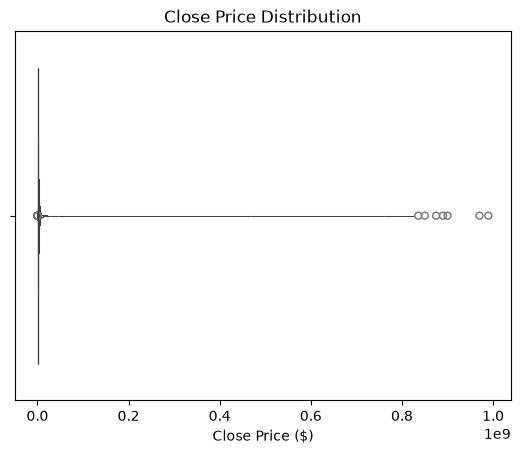

In [26]:
# boxplot for close price distribution
sns.boxenplot(x=df_sold_cleaned["ClosePrice"])
plt.title("Close Price Distribution")
plt.xlabel("Close Price ($)")
plt.show()

Most of properties have much lower close price values, but a few extremely large prices strech out that distribution is highly right skewed. There are properties that are potential outliers. We will identify those outliers considering business and statistical rule later.

Let's exclude the extreme properties in temperatory over 99% close price properties for identifying broad trend of close price.

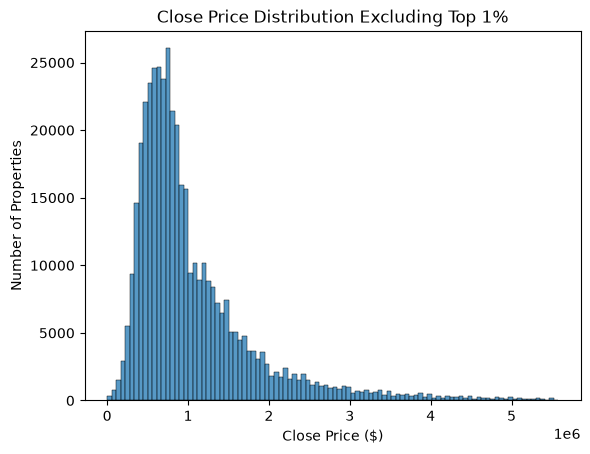

In [27]:
upper_limit = df_sold_cleaned["ClosePrice"].quantile(0.99)

sns.histplot(df_sold_cleaned[df_sold_cleaned["ClosePrice"] <= upper_limit]["ClosePrice"], bins=100)
plt.title("Close Price Distribution Excluding Top 1%")
plt.xlabel("Close Price ($)")
plt.ylabel("Number of Properties")
plt.show()

The close price distribution is right skewed. Most of properties sold below about 1.3 million dollars, but a small number of expensive properties increase the mean. 

### 1) Close Price + List Price & Original List Price.

In the sold dataset, list price and original list price are there because a sold property still has its listing history, explaining how the sale happened. 

- List price is the most recent asking price before sold by the seller and the seller's broker

- Original list price is the initial agreement between the seller and seller's broker.

We will explore how those prices went forward until the sold price.

Let's check if there is error listed for list and original list price aamong properties that has been sold.

In [28]:
print("0 dollars of listed price:", df_sold[df_sold["ListPrice"]==0].shape[0])
print("invalid of list price:", df_sold[df_sold["ListPrice"]<0].shape[0] )
print()
print("0 dollars of orginal listed price:", df_sold[df_sold["OriginalListPrice"]==0].shape[0])
print("invalid of original list price:", df_sold[df_sold["OriginalListPrice"]<0].shape[0] )


0 dollars of listed price: 0
invalid of list price: 0

0 dollars of orginal listed price: 2
invalid of original list price: 0


In [29]:
#
df_sold[["ClosePrice","ListPrice", "OriginalListPrice"]][df_sold["OriginalListPrice"]==0]

,ClosePrice,ListPrice,OriginalListPrice
198749,1905000.0,1475000.0,0.0
358107,267900.0,262900.0,0.0


The original price contain two records with value 0 dollars. Because property cannot have an original asking price 0 dollars with list price was listed, it would be considered as invalid values.

We will drop those two properties with previously missing values of oringal listing price of 0.18%.

In [30]:
df_sold_cleaned= df_sold_cleaned[df_sold_cleaned["OriginalListPrice"]>0].dropna(subset=["OriginalListPrice"])



We will make new features of **SaleListRatio**, **DiffCloseList**, and **PriceReduction**. 

- **SaleListRatio** measures whether homes sold above or below the final asking price.

- **DiffCloseList** measures the price difference between the final sale and final list price. 

- **PriceReduction** measures whether the seller reduced the price from original list price before sale.

There were couple missing values in the sold dataset that close price has 0.0002%, list price has 0% and original list price has 0.1835%. We will remove those minimal missing price properties that will cause less performance analysis.

In [31]:
# make new features of the performance among close, list, original list prices

df_sold_cleaned["SaleListRatio"] = df_sold_cleaned["ClosePrice"] / df_sold_cleaned["ListPrice"]

df_sold_cleaned["DiffCloseList"] = df_sold_cleaned["ClosePrice"] - df_sold_cleaned["ListPrice"]

df_sold_cleaned["PriceReduction"] = df_sold_cleaned["OriginalListPrice"] - df_sold_cleaned["ListPrice"]


Let's explore those values.

In [32]:
df_sold_cleaned[["SaleListRatio","DiffCloseList", "PriceReduction"]].describe()

,SaleListRatio,DiffCloseList,PriceReduction
count,4.292820e+05,4.292820e+05,4.292820e+05
mean,1.084086e+00,5.148261e+04,8.681582e+04
std,8.767779e+00,6.052136e+06,6.542228e+06
min,9.591326e-07,-2.750000e+07,-1.035000e+07
25%,9.763643e-01,-1.990000e+04,0.000000e+00
50%,1.000000e+00,0.000000e+00,0.000000e+00
75%,1.019725e+00,1.500000e+04,1.000000e+04
max,1.153846e+03,9.885210e+08,1.388810e+09


**Ratio**

- The median is 1, meaning the typical home sold exactly at asking price, asking between 0.97 and 1.0197.

-  Most homes sold from about 2.36% were below asking, and 1.96% above asking the housing price.

- The mean is 1.084, which it is higher than median. This probably because of extreme outliers, especially 1153.85. This is not realistic for normal housing data. It means one property's close price was over 1,153 times its listing price. This probably happened because list price was extremely low, wrong, or entered invalid value.

- We might be cautious on interpreting mean ratio.

**Difference of close and list price**

- The median 0, presenting that typical housing sold at asking price, asking between 19,900 dollars below asking, and 15,000 dollars above asking.

- The max of difference was 988,521,000 dollars that extremely large and likely an outlier or data quality issue. That huge value is pulling the mean upward to 51,385 dollars differences between close and listing price.

- We might need to be cautious intperting mean difference.

**Price Reduction**

- The median 0, presenting that typical houses had no price reduction, but 75% of properties were 10,000 dollars or less reduction been sold. 

- The max reduction price was 1.39 billion dollars, that original price was 1.39 billion dollars higher than final sale price. This is likely error or unusual commercial record. 

In [33]:
df_sold_cleaned.loc[df_sold_cleaned["SaleListRatio"].idxmax()]

Flooring                                              Wood
ViewYN                                                 NaN
PoolPrivateYN                                        False
OriginalListPrice                                 325000.0
ListingKey                                      1077754080
CloseDate                                       2024-08-14
ClosePrice                                     375000000.0
ListAgentFirstName                                     Rob
ListAgentLastName                                  Baldwin
Latitude                                         38.025073
Longitude                                      -122.029107
UnparsedAddress                             168 Norman ave
PropertyType                                   Residential
LivingArea                                          1047.0
ListPrice                                         325000.0
DaysOnMarket                                             7
ListOfficeName                 Baldwin Property Manageme

This is the property of ratio that was maximum 1,153 times higher sold prices than it was listed price. The listed and originial list price were 325,000 dollars, and sold price was 375,000,000 dollars. The living area of 1047sqft and lot size of 0.1278 with 2 bedrooms and 1 bathroom is decent residential property of  single family residence. It is likely data entry error. We will drop this property.

In [34]:
df_sold_cleaned.loc[df_sold_cleaned["DiffCloseList"].idxmax()]

Flooring                                                  NaN
ViewYN                                                   True
PoolPrivateYN                                            True
OriginalListPrice                                    979000.0
ListingKey                                         1133720285
CloseDate                                          2025-10-31
ClosePrice                                        989500000.0
ListAgentFirstName                                      Bryan
ListAgentLastName                                     Van Zee
Latitude                                            34.395149
Longitude                                         -118.560797
UnparsedAddress                              25902 Matel Road
PropertyType                                      Residential
LivingArea                                             2289.0
ListPrice                                            979000.0
DaysOnMarket                                               21
ListOffi

This maximum difference of close price of 989,500,000 dollars and listing price of 979,000 dollars property shows ratios above 1,000 times higher that the value is implausible and likely contains extra zeros, and it will be flagged and exclude it.

In [35]:
df_sold_cleaned.loc[df_sold_cleaned["PriceReduction"].idxmax()]

Flooring                                        Wood
ViewYN                                          True
PoolPrivateYN                                  False
OriginalListPrice                       1390000000.0
ListingKey                                1077473007
CloseDate                                 2025-02-21
ClosePrice                                 1120000.0
ListAgentFirstName                           Marlene
ListAgentLastName                            Dymally
Latitude                                   33.962926
Longitude                                -118.322476
UnparsedAddress                   2704 W 83rd Street
PropertyType                             Residential
LivingArea                                    2186.0
ListPrice                                  1190000.0
DaysOnMarket                                     205
ListOfficeName                       Marlene Dymally
BuyerOfficeName                 Pacific Playa Realty
ListAgentFullName                    Marlene D

This property of original list price is 1,390,000,000 dollars, but the list price was 1,190,000 dollars with sold 1,120,000 dollars. This price reduction between original and list price was 1,388,810,000 dollars shows the original list price itself is not credible for a 2,186-square-foot single-family home in Inglewood. The likely intended value was probably $1,390,000, meaning three extra zeros were entered. We will treat this as data entry error as well.


In [36]:
df_sold_cleaned = df_sold_cleaned.drop(index = 
                         list({
                             df_sold_cleaned["SaleListRatio"].idxmax(),
                             df_sold_cleaned["DiffCloseList"].idxmax(),
                             df_sold_cleaned["PriceReduction"].idxmax()
                         }
                        )
                    )


In [ ]:
row_df.shape[0] - df_sold_cleaned.shape[0]

row_df = df_sold_cleaned.shape[0]

### 2) Outliers Close Price

## 2. Property Subtype

We will explore property subtype for understanding properties performance in sold houses. There is no implicit missing values, but there is explicit of 0.2% properties in the previous observation.

In [37]:
# drop explicit missing value for property subtype
df_sold_cleaned = df_sold_cleaned.dropna(subset=["PropertySubType"])
df_sold_cleaned["PropertySubType"].isna().sum()

np.int64(0)

Now we will identify distribution of property subtype.

In [38]:
# list all proportion of values in property subtype
prob_subtype = df_sold_cleaned["PropertySubType"].value_counts(normalize=True)*100
prob_subtype

PropertySubType
SingleFamilyResidence    74.980686
Condominium              16.532189
Townhouse                 5.883547
ManufacturedOnLand        1.293503
Duplex                    0.551057
StockCooperative          0.399114
Cabin                     0.112966
Triplex                   0.081923
MixedUse                  0.049481
Quadruplex                0.034777
BoatSlip                  0.020773
OwnYourOwn                0.014471
MobileHome                0.013304
ManufacturedHome          0.009803
Loft                      0.006769
Timeshare                 0.004201
CoOwnership               0.003968
Farm                      0.003501
Studio                    0.002567
DeededParking             0.001400
Name: proportion, dtype: float64

In [39]:
subtype_count = df_sold_cleaned["PropertySubType"].value_counts()
subtype_count

PropertySubType
SingleFamilyResidence    321254
Condominium               70832
Townhouse                 25208
ManufacturedOnLand         5542
Duplex                     2361
StockCooperative           1710
Cabin                       484
Triplex                     351
MixedUse                    212
Quadruplex                  149
BoatSlip                     89
OwnYourOwn                   62
MobileHome                   57
ManufacturedHome             42
Loft                         29
Timeshare                    18
CoOwnership                  17
Farm                         15
Studio                       11
DeededParking                 6
Name: count, dtype: int64

Most of the properties are single family residence with 74%, and condominum about 16%, then town house with about 6%. 

Let's group into "others" that has less than 100 properties in each subtypes for easier visualization in temporatory.

In [40]:
# index over 100 properties of property subtypes
count_subtype_common_index = subtype_count[subtype_count > 100].index

# group into others that are less than 100
subtype_grouped = (df_sold_cleaned["PropertySubType"]
                 .where(df_sold_cleaned["PropertySubType"]
                    .isin(count_subtype_common_index), "Others"
                 )
                )

# show distribution of counts in each subtypes
count_subtype_common = subtype_grouped.value_counts(normalize=True)
count_subtype_common

PropertySubType
SingleFamilyResidence    0.749807
Condominium              0.165322
Townhouse                0.058835
ManufacturedOnLand       0.012935
Duplex                   0.005511
StockCooperative         0.003991
Cabin                    0.001130
Triplex                  0.000819
Others                   0.000808
MixedUse                 0.000495
Quadruplex               0.000348
Name: proportion, dtype: float64

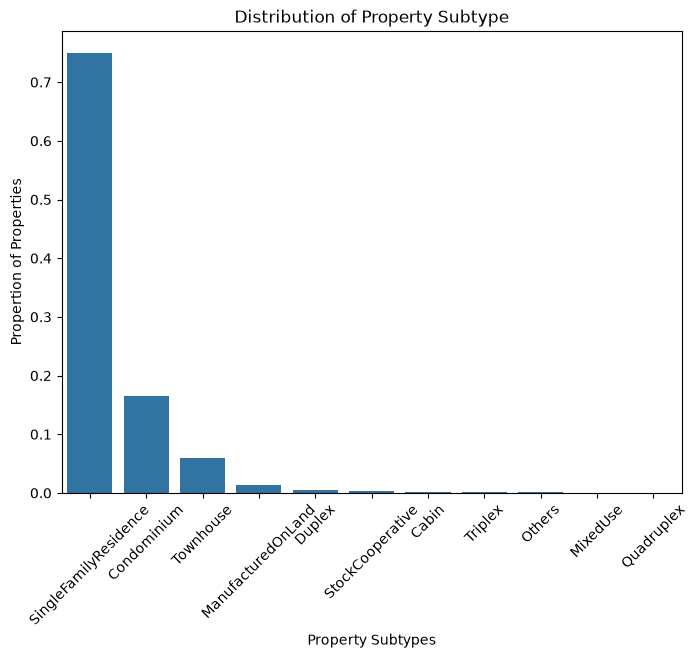

In [41]:
# boxplot for distribution 
plt.figure(figsize=(8,6))
sns.barplot(x=count_subtype_common.index, y = count_subtype_common)
plt.title("Distribution of Property Subtype")
plt.xticks(rotation=45)
plt.xlabel("Property Subtypes")
plt.ylabel("Propertion of Properties")
plt.show()

The distribution of property subtypes is highly uneven. Single family residences make up approximately three-quarters of the sold records, followed by condominiums and townhouses. Manufactured homes, duplexes, stock cooperatives, cabins, triplexes, mixed-use properties, and quadruplexes represent only a small fraction of the dataset. This imbalance means that overall price and market summaries will largely reflect the behavior of single-family homes rather than the entire residential market.

### 1) Property Subtype & Close Price

We will identify the relationship between property subtypes and close price using median due to right skewed close price, sorting based on median price descending order.  

In [42]:
subtype_closeprice = (df_sold_cleaned.groupby("PropertySubType")["ClosePrice"]
                      .agg(
                          count = "count",
                          min = "min",
                          q1 = lambda x : x.quantile(0.25),
                          median = "median",
                          q3 = lambda x : x.quantile(0.75),
                          IQR = lambda x : x.quantile(0.75) - x.quantile(0.25),
                          max = "max"

                      )
                      .sort_values("median", ascending=False))
subtype_closeprice

,count,min,q1,median,q3,IQR,max
PropertySubType,,,,,,,
Farm,15,490000.00,1146250.0,1425000.0,1825000.00,678750.00,4200000.0
Quadruplex,149,285000.00,825000.0,1250500.0,1750000.00,925000.00,11995000.0
Triplex,351,120000.00,782500.0,1125000.0,1572000.00,789500.00,7100000.0
Duplex,2361,35000.00,675000.0,912000.0,1350000.00,675000.00,14000000.0
SingleFamilyResidence,321254,1.15,625000.0,895000.0,1430000.00,805000.00,970000000.0
Townhouse,25208,675.00,645687.5,800000.0,1110000.00,464312.50,850000000.0
MixedUse,212,17300.00,448750.0,687500.0,1100000.00,651250.00,11195000.0
Loft,29,316000.00,565000.0,680000.0,780000.00,215000.00,1315000.0
Condominium,70832,464.00,480000.0,627000.0,850000.00,370000.00,890000000.0


- **Farm** has the highest median close price at about $1.43 million dollars within $678,750 in the range of $1,146,250 to $1,825,000, then **Quadruplex** is about $1.25 million within $925,000 in the range of $825,000 to $1,750,000 and **Triplex** at about $1.13 million within $789,500 in the range of $782,500 to $1,572,000. However, **Farm** has 15 records so median is much less stable than other higher number of properties. 
  

- Among the large categories, **single family** has a typical sold price of about $895,000 within $805,000 dollars in the range $625,000 to $1.43 million, than **townhouse** at $800,000 within $464,313 in the range of $645,688 to $1.11 million, and **condominium** at $627,000 within $370,000 in the range of $480,000 to $850,000. This suggests that detached single-family properties generally sell for more than attached residential types.
  

- However, there is likely data entry errors as no legitmate sales.** single family** lowest sold price is $1.15, **townhouse** of $675, and **condominium** of $464. 

- The most reliable interpetation would be **single family**, **condominium**, **townhouse**, and **manufactured** on land due to high number of properties compare to others. Other property subtypes needs to be cautious on interpretations.

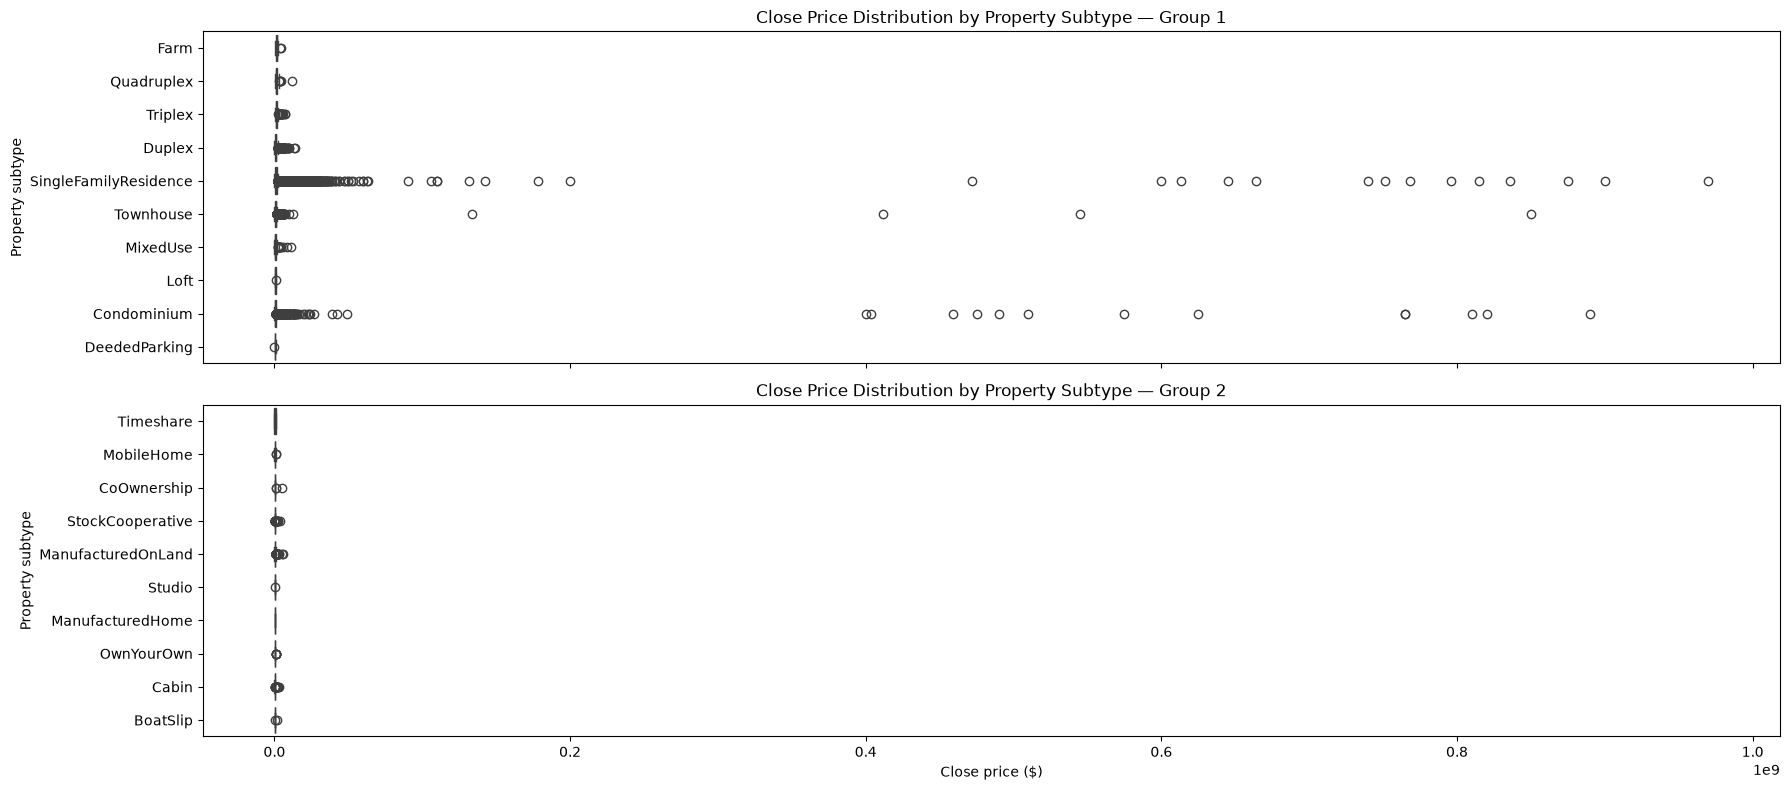

In [43]:
subtype_order = (
    df_sold_cleaned.groupby("PropertySubType")["ClosePrice"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

# Divide the subtype list into two halves
midpoint = len(subtype_order) // 2

first_half = subtype_order[:midpoint]
second_half = subtype_order[midpoint:]

# Create two plots in one row
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(18, 8),
    sharex=True
)

sns.boxplot(
    data=df_sold_cleaned[df_sold_cleaned["PropertySubType"].isin(first_half)],
    x="ClosePrice",
    y="PropertySubType",
    order=first_half,
    ax=axes[0]
)

axes[0].set_title("Close Price Distribution by Property Subtype — Group 1")
axes[0].set_xlabel("Close price ($)")
axes[0].set_ylabel("Property subtype")

sns.boxplot(
    data=df_sold_cleaned[df_sold_cleaned["PropertySubType"].isin(second_half)],
    x="ClosePrice",
    y="PropertySubType",
    order=second_half,
    ax=axes[1]
)

axes[1].set_title("Close Price Distribution by Property Subtype — Group 2")
axes[1].set_xlabel("Close price ($)")
axes[1].set_ylabel("Property subtype")

plt.tight_layout()
plt.show()

## 3. Living Area

There is explicit missing values of living area about 0.06% and we will exclude those minor properties. 

In [44]:
df_sold = df_sold.dropna(subset=["LivingArea"])
df_sold["LivingArea"].isna().sum() 

np.int64(0)

Let's check if there is invalid values.

In [45]:
# identify rows of properties that has 0 or negative living area size (invalid)
print("invalid living area size:", df_sold[df_sold["LivingArea"]<0].shape[0])
print("0 living area size:", df_sold_cleaned[df_sold_cleaned["LivingArea"]==0].shape[0])

invalid living area size: 0
0 living area size: 153


There is 153 rows that are living area size is 0 and there is no negative, and it usually means the value is missing, unknown, or incorrectly recoreded rather than having no living space. We will exclude those properties as well.

In [46]:
# flag invalid close price
df_sold["InvalidValue"] = df_sold["LivingArea"] < 0

# exclude invalid values
df_sold_cleaned = df_sold_cleaned[df_sold_cleaned['LivingArea']>=0]
(df_sold_cleaned["LivingArea"]<=0).sum()

np.int64(153)

In [47]:
df_sold["LivingArea"].describe()

count    4.298300e+05
mean     1.904188e+03
std      2.597918e+04
min      0.000000e+00
25%      1.248000e+03
50%      1.644000e+03
75%      2.221000e+03
max      1.702132e+07
Name: LivingArea, dtype: float64

The overall living area size is about 1905 sqft as mean value, and typical size is 1645 sqft across California sold houses. The maximum size is 17,021,320 sqft treated extreme outlier as luxury property. The distribution would be right skewed that mean value was pulling upward due to minor extreme outliers.  

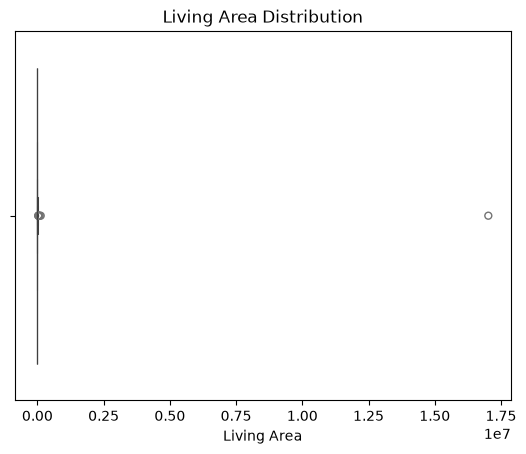

In [48]:
sns.boxenplot(x=df_sold["LivingArea"])
plt.title("Living Area Distribution")
plt.xlabel("Living Area")
plt.show()

There is extreme outlier property. We will identify living area distribution excluding extreme outlier temperatory to show distribution closely.

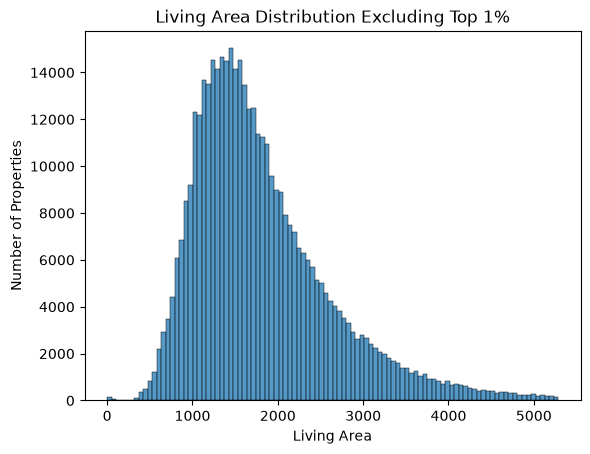

In [49]:
upper_limit = df_sold["LivingArea"].quantile(0.99)

sns.histplot(df_sold[df_sold["LivingArea"] <= upper_limit]["LivingArea"], bins=100)
plt.title("Living Area Distribution Excluding Top 1%")
plt.xlabel("Living Area")
plt.ylabel("Number of Properties")
plt.show()

Excluding top 1% living area size that is over 3680.5 sqft, the distribution shows right skewed still. The typical house sold area size is 1645 sqft within 974 sqft in the range of 1248 sqft to 2222 sqft in the middle 50% of properties.

We consider outliers 3680.5 sqft as upper bound that has many large or luxury homes exceed sizes under IQR rule. 

In [ ]:
row_df.shape[0] - df_sold_cleaned.shape[0]

row_df = df_sold_cleaned.shape[0]

## 3) Lot Size

Let's check if there is invalid value and exclude previous 7.8% of explicit missing values as well.

In [50]:
# drop the missing values of lot size
df_sold = df_sold.dropna(subset=["LotSizeAcres"])
df_sold["LotSizeAcres"].isna().sum()

np.int64(0)

In [51]:
print("invalid lot size:", df_sold[df_sold["LotSizeAcres"]<0].shape[0])
print("0 lot size:", df_sold_cleaned[df_sold_cleaned["LotSizeAcres"]==0].shape[0])

invalid lot size: 0
0 lot size: 8968


There are no invliad values for lot size, but there is 0 acres lot size of 8968 properties. There is no adjustment for invalid values for lot size.

In [52]:
df_sold["LotSizeAcres"].describe()

count    3.962460e+05
mean     6.409102e+01
std      1.569827e+04
min      0.000000e+00
25%      1.200000e-01
50%      1.664000e-01
75%      2.732000e-01
max      7.810698e+06
Name: LotSizeAcres, dtype: float64

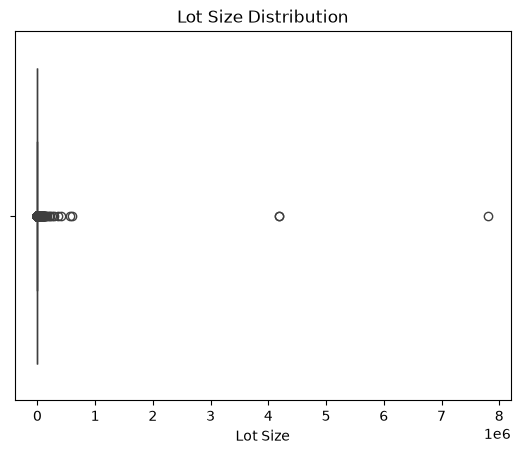

In [53]:
sns.boxplot(x=df_sold["LotSizeAcres"])
plt.title("Lot Size Distribution")
plt.xlabel("Lot Size")
plt.show()

In [54]:
upper_limit = df_sold["LotSizeAcres"].quantile(0.99)


print(df_sold[df_sold["LotSizeAcres"]>=upper_limit].shape)
print(df_sold[df_sold["LotSizeAcres"]>=upper_limit]["LotSizeAcres"].sort_values(ascending=False))
df_sold[df_sold["LotSizeAcres"]>=upper_limit].head()

(3967, 53)
47019     7.810698e+06
286304    4.187292e+06
253419    4.187292e+06
153531    6.048240e+05
145526    5.718370e+05
50050     4.064320e+05
350318    3.549900e+05
199922    2.870600e+05
209670    2.480810e+05
198643    2.143360e+05
368970    2.030000e+05
195600    1.585990e+05
91273     1.451600e+05
328515    1.276310e+05
23749     1.272050e+05
401636    1.209720e+05
119191    1.179440e+05
87684     1.167410e+05
384674    1.160540e+05
307773    9.409000e+04
130702    8.995000e+04
227294    8.903700e+04
378223    8.889500e+04
332693    8.886200e+04
342446    8.799100e+04
135335    8.799100e+04
133838    8.743000e+04
393379    8.712000e+04
117672    8.712000e+04
132075    8.624800e+04
369214    8.476800e+04
167564    8.128200e+04
347683    8.011200e+04
313614    7.248700e+04
227321    7.149600e+04
260979    6.839300e+04
201303    6.779016e+04
107053    6.401300e+04
269110    6.359800e+04
341133    6.359700e+04
377050    6.011300e+04
270970    6.011200e+04
389194    5.924100e+04


,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,...,Stories,HighSchool,Levels,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerAgencyCompensationType,BuyerAgencyCompensation,InvalidValue
2,Wood,True,False,184500.0,1048590625,2024-01-01,186500.0,Nathan,Barkley,NaN,...,1.0,NaN,One,False,0.0,NaN,92026,NaN,NaN,False
7,NaN,True,False,610000.0,1054027980,2024-01-01,610000.0,Tyson,Dexter,34.151757,...,1.0,NaN,One,False,0.0,Las Virgenes,91302,NaN,NaN,False
73,NaN,True,False,819000.0,1046466497,2024-01-02,720000.0,Jessica,Simmons,39.821453,...,1.0,NaN,One,False,2.0,Chico Unified,95973,NaN,NaN,False
251,"Carpet,Tile",False,False,529000.0,1045232329,2024-01-02,460000.0,Laura,Benvenuto,33.709040,...,1.0,NaN,One,False,0.0,Irvine Unified,92660,NaN,NaN,False
375,NaN,True,False,325000.0,1044789810,2024-01-02,250000.0,Andre,Holmes,39.065973,...,1.0,NaN,One,False,0.0,Lake,95423,NaN,NaN,False


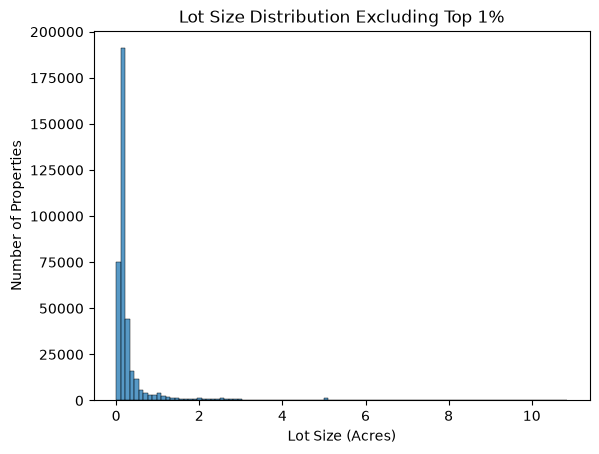

In [55]:
sns.histplot(df_sold[df_sold["LotSizeAcres"] <= upper_limit]["LotSizeAcres"], bins=100)
plt.title("Lot Size Distribution Excluding Top 1%")
plt.xlabel("Lot Size (Acres)")
plt.ylabel("Number of Properties")
plt.show()

## 4) Bedrooms

In [56]:
df_sold["BedroomsTotal"].describe()

count    396246.000000
mean          3.261996
std           1.054846
min           0.000000
25%           3.000000
50%           3.000000
75%           4.000000
max          45.000000
Name: BedroomsTotal, dtype: float64

In [57]:
df_sold["BedroomsTotal"].value_counts(normalize=True).sort_values(ascending=False)*100

BedroomsTotal
3.0     40.308798
4.0     27.879903
2.0     18.579620
5.0      8.292071
1.0      2.771006
6.0      1.463232
7.0      0.297542
0.0      0.242526
8.0      0.099181
9.0      0.032051
10.0     0.016152
11.0     0.005047
12.0     0.004543
13.0     0.002019
15.0     0.001767
16.0     0.001262
14.0     0.000757
34.0     0.000252
23.0     0.000252
31.0     0.000252
18.0     0.000252
17.0     0.000252
45.0     0.000252
19.0     0.000252
20.0     0.000252
22.0     0.000252
24.0     0.000252
Name: proportion, dtype: float64

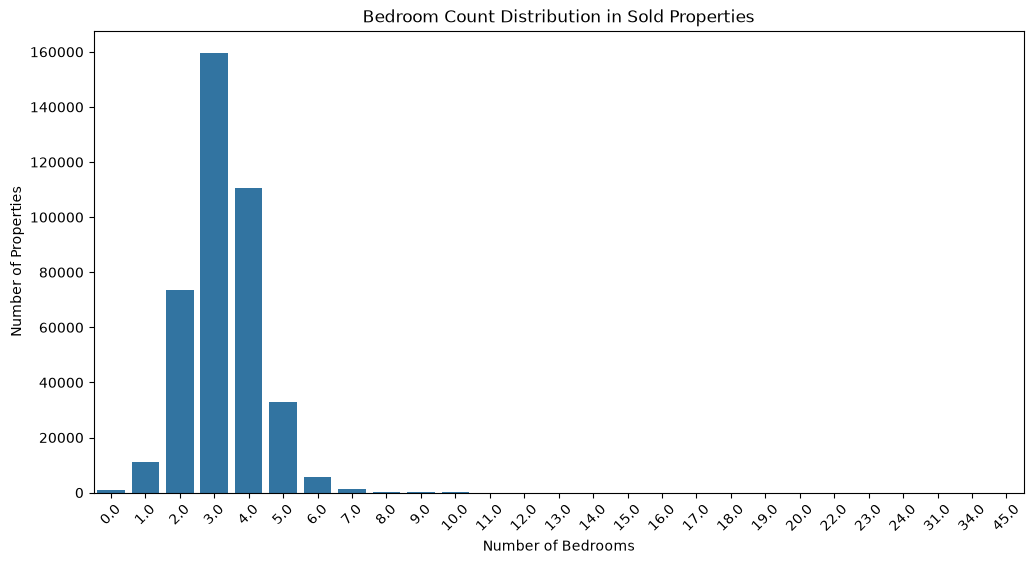

In [58]:
plt.figure(figsize=(12, 6))
sns.countplot(x="BedroomsTotal", data = df_sold)
plt.xticks(rotation=45)
plt.title("Bedroom Count Distribution in Sold Properties")
plt.xlabel('Number of Bedrooms')
plt.ylabel("Number of Properties")
plt.show()

## 5) Bathrooms

In [59]:
df_sold['BathroomsTotalInteger'].describe()

count    396190.000000
mean          2.550069
std           1.112927
min           0.000000
25%           2.000000
50%           2.000000
75%           3.000000
max         153.000000
Name: BathroomsTotalInteger, dtype: float64

In [60]:
df_sold["BathroomsTotalInteger"].value_counts(normalize=True).sort_values(ascending=False)

BathroomsTotalInteger
2.0      0.436079
3.0      0.331490
1.0      0.108448
4.0      0.075201
5.0      0.029319
6.0      0.011431
7.0      0.004018
8.0      0.001678
9.0      0.000782
0.0      0.000709
10.0     0.000366
11.0     0.000174
12.0     0.000114
13.0     0.000068
14.0     0.000038
15.0     0.000015
16.0     0.000013
20.0     0.000008
18.0     0.000008
21.0     0.000008
22.0     0.000008
17.0     0.000005
27.0     0.000005
153.0    0.000003
25.0     0.000003
45.0     0.000003
31.0     0.000003
35.0     0.000003
23.0     0.000003
Name: proportion, dtype: float64

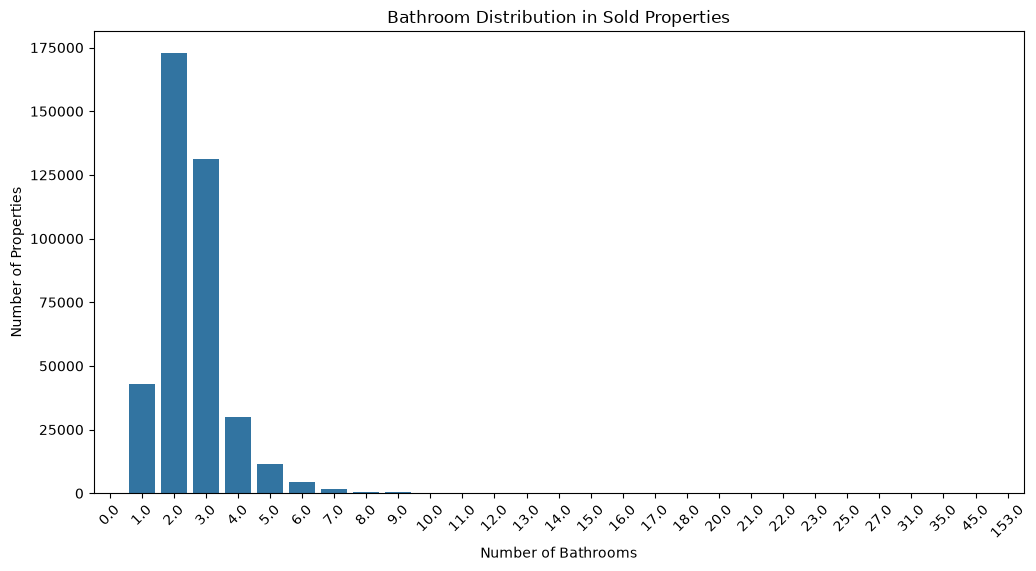

In [61]:
plt.figure(figsize=(12, 6))
sns.countplot(x="BathroomsTotalInteger", data = df_sold)
plt.xticks(rotation=45)
plt.title('Bathroom Distribution in Sold Properties')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Number of Properties')
plt.show()

## 6) Days on Market

There is no explicit and implicit missing values for days on market feature. Let's identify if there is invalid value.

In [62]:
print("invalid days on market:", df_sold_cleaned[df_sold_cleaned["DaysOnMarket"]<0].shape[0])
print("0 days in market:", df_sold_cleaned[df_sold_cleaned["DaysOnMarket"]==0].shape[0])

invalid days on market: 49
0 days in market: 16454


There is 16433 properties that were listed and sold that went pending or closed on the same day. However, the negative days on market are impossible entries for sold markets. We will drop those invalid listed market days.

In [63]:
df_sold_cleaned = df_sold_cleaned[df_sold_cleaned["DaysOnMarket"]>=0]
(df_sold_cleaned["DaysOnMarket"]<0).sum()

np.int64(0)

In [64]:
df_sold["DaysOnMarket"].describe()

count    396246.000000
mean         37.540061
std          54.251298
min        -288.000000
25%           8.000000
50%          18.000000
75%          48.000000
max       12430.000000
Name: DaysOnMarket, dtype: float64

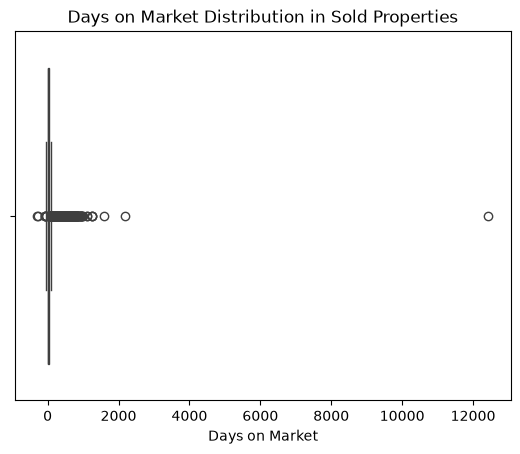

In [65]:
sns.boxplot(x=df_sold["DaysOnMarket"])
plt.title("Days on Market Distribution in Sold Properties")
plt.xlabel("Days on Market")
plt.show()

In [66]:
neg_days_market = df_sold[df_sold["DaysOnMarket"]<0]

print(neg_days_market.shape)
neg_days_market["DaysOnMarket"]

(48, 53)


7458      -36
12442     -10
20313     -10
21216     -13
23931     -13
24711      -6
24751     -10
25423      -2
27863      -2
27937     -19
30096      -5
31161     -14
32073      -3
33063     -58
34560      -1
34623     -48
34982     -57
35255      -6
49474      -2
68211      -2
68410     -43
85394     -84
88858     -18
90737      -1
127505    -56
146190     -8
172698     -6
203477   -288
229290     -4
233340     -3
234479    -12
246319    -34
263281     -7
265843    -26
271810     -9
282102    -63
300578    -14
321723    -21
327790     -7
329693     -4
331067     -2
334152    -65
334230   -265
346723     -4
371718    -14
411387    -39
417517     -4
421981     -1
Name: DaysOnMarket, dtype: int64

In [67]:
upper_limit  = df_sold["DaysOnMarket"].quantile(0.99)

print(df_sold[df_sold["DaysOnMarket"]>=upper_limit].shape)
print(df_sold[df_sold["DaysOnMarket"]>=upper_limit]["DaysOnMarket"].sort_values(ascending=False))
df_sold[df_sold["DaysOnMarket"]>=upper_limit].head()

(3971, 53)
105233    12430
382881     2177
354688     1580
352052     1262
335485     1256
377363     1243
243268     1099
425803     1098
38721       985
214592      974
214285      966
387873      944
33871       943
166085      935
178899      934
11966       912
353420      894
355875      886
204397      877
83723       864
231664      855
333586      844
13773       833
421016      831
184888      825
144147      820
313352      820
385397      806
285478      798
195088      788
140888      780
380362      773
418094      768
84055       768
325018      766
68569       765
215564      763
83971       760
390743      756
347634      755
182899      744
326866      731
422861      730
272572      728
133768      728
198966      728
267173      727
323739      726
416847      723
416812      723
122308      723
76830       722
83653       717
181854      714
115831      708
425799      705
165798      705
403752      702
405841      695
331729      695
405853      689
217198      6

,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,...,Stories,HighSchool,Levels,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerAgencyCompensationType,BuyerAgencyCompensation,InvalidValue
334,"Carpet,Tile,Vinyl",True,False,399000.0,1031732455,2024-01-02,345000.0,Shelly,Jouett,37.496895,...,2.0,NaN,Two,False,2.0,Mariposa County Unified,95338,NaN,NaN,False
386,NaN,False,NaN,8500000.0,1033955925,2024-01-02,7500000.0,Tim,Allen,NaN,...,NaN,NaN,NaN,False,0.0,Carmel Unified,93923,NaN,NaN,False
873,NaN,True,False,1149000.0,1031747562,2024-01-03,1150000.0,Ghydan,Rabadi,34.140591,...,1.0,NaN,One,False,2.0,Glendale Unified,91204,NaN,NaN,False
897,"Carpet,Tile",True,False,390000.0,1033337195,2024-01-03,350000.0,Marlene,Bridges,33.607355,...,1.0,NaN,One,False,0.0,Saddleback Valley Unified,92637,NaN,NaN,False
1016,Laminate,True,False,49000.0,1028750661,2024-01-03,40000.0,LEYLA,AFZALNIA,35.787066,...,1.0,NaN,One,False,2.0,ABC Unified,93562,NaN,NaN,False


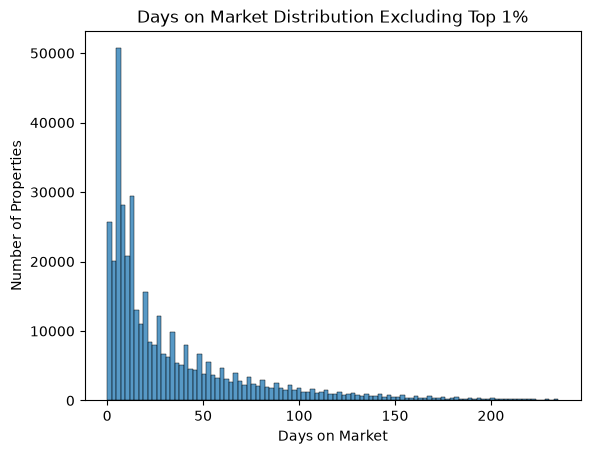

In [68]:
df_sold = df_sold[df_sold["DaysOnMarket"]>= 0]

sns.histplot(df_sold[df_sold["DaysOnMarket"] <= upper_limit]["DaysOnMarket"], bins=100)
plt.title("Days on Market Distribution Excluding Top 1%")
plt.xlabel("Days on Market")
plt.ylabel("Number of Properties")
plt.show()

In [69]:
def dom_split(days):
    if days <=30:
        return "fast sale"
    
    elif days>30 and days <=90:
        return "moderate sale"
    
    elif days >90 and days<=180:
        return "slow sale"
    
    elif days > 180:
        return "long time sale"

df_sold["DOM_category"] = df_sold["DaysOnMarket"].apply(dom_split)

df_sold["DOM_category"].value_counts(normalize=True).sort_values(ascending=False)

DOM_category
fast sale         0.629854
moderate sale     0.261983
slow sale         0.085975
long time sale    0.022188
Name: proportion, dtype: float64

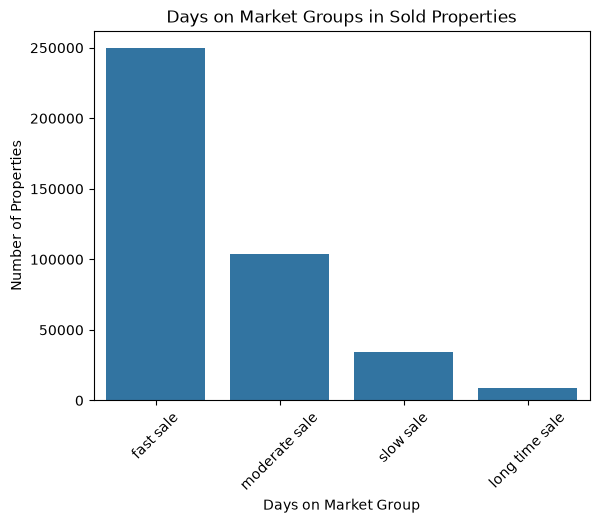

In [70]:
sns.countplot(x="DOM_category",data= df_sold)

plt.title("Days on Market Groups in Sold Properties")
plt.xlabel("Days on Market Group")
plt.ylabel("Number of Properties")
plt.xticks(rotation=45)
plt.show()

In [ ]:
row_df.shape[0] - df_sold_cleaned.shape[0]

row_df = df_sold_cleaned.shape[0]

## 7) Year Built

In [74]:
df_sold_cleaned["YearBuilt"].describe()

count    427820.000000
mean       1978.624721
std          26.281167
min        1776.000000
25%        1960.000000
50%        1979.000000
75%        1999.000000
max        2026.000000
Name: YearBuilt, dtype: float64

In [75]:
df_sold_cleaned["PropertyAge"] = 2026 - df_sold_cleaned["YearBuilt"]

df_sold_cleaned["PropertyAge"].value_counts(normalize=True).sort_values(ascending=False)

PropertyAge
37.0     0.021462
2.0      0.019422
38.0     0.019008
47.0     0.018758
46.0     0.018339
39.0     0.018050
36.0     0.017991
53.0     0.017559
41.0     0.017419
21.0     0.017344
40.0     0.017122
48.0     0.017089
49.0     0.016811
54.0     0.016395
71.0     0.016180
22.0     0.016023
20.0     0.015925
1.0      0.015677
62.0     0.015656
42.0     0.015006
52.0     0.014602
23.0     0.014312
45.0     0.014223
61.0     0.013686
63.0     0.013679
70.0     0.013648
55.0     0.013450
64.0     0.013223
72.0     0.013206
76.0     0.013083
66.0     0.013062
67.0     0.013003
50.0     0.012921
3.0      0.011774
73.0     0.011594
51.0     0.011561
24.0     0.011393
19.0     0.011194
56.0     0.010960
65.0     0.010916
26.0     0.010895
35.0     0.010881
74.0     0.010530
75.0     0.010507
25.0     0.010306
68.0     0.010266
69.0     0.010240
43.0     0.010070
57.0     0.009756
27.0     0.009633
58.0     0.009443
60.0     0.008751
8.0      0.008630
78.0     0.008618
28.0     0.00851

Let's check if there is invalid age of properties.

In [76]:
print("invalid age of properties:", df_sold_cleaned[df_sold_cleaned["PropertyAge"]<0].shape[0])
print("Brand new properties:", df_sold_cleaned[df_sold_cleaned["PropertyAge"]==0].shape[0])

invalid age of properties: 0
Brand new properties: 999


There is no invalid age properties that was build, and there are brand new properties of 999 that were built in this year 2026.

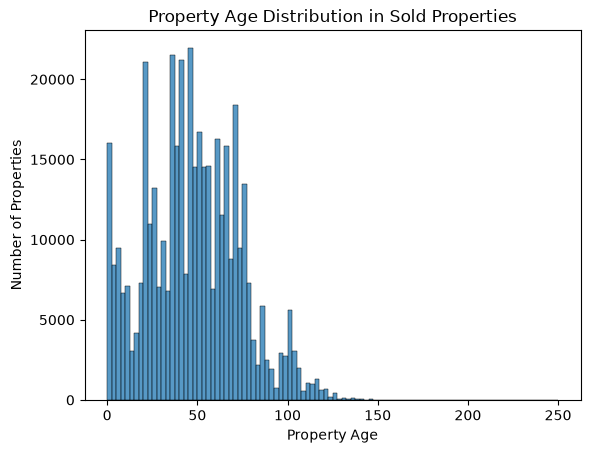

In [77]:
sns.histplot(df_sold_cleaned["PropertyAge"], bins=100)

plt.title("Property Age Distribution in Sold Properties")
plt.xlabel("Property Age")
plt.ylabel("Number of Properties")
plt.show()

In [ ]:
def age_split(ages):
    if ages<=5:
        return "0-5"
    
    elif ages > 5 and ages<=10:
        return "6-10"
    
    elif ages>10 and ages <=20:
        return "11-20"
    
    elif ages>20 and ages<=40:
        return "21-40"
    
    elif ages>40 and ages<=70:
        return "41-70"
    
    elif ages>70:
        return "70+"

df_sold["PropertyAgeGroup"] = df_sold["PropertyAge"].apply(age_split)

df_sold["PropertyAgeGroup"].value_counts(normalize=True)

PropertyAgeGroup
41-70    0.392328
21-40    0.248648
70+      0.207066
11-20    0.058904
0-5      0.058616
6-10     0.034437
Name: proportion, dtype: float64

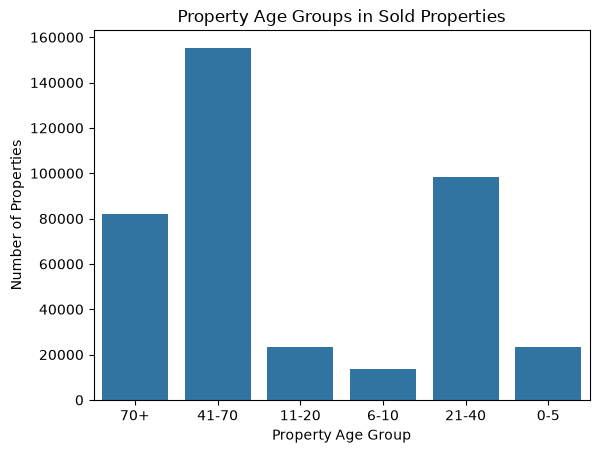

In [ ]:
sns.countplot(x="PropertyAgeGroup", data = df_sold)

plt.title("Property Age Groups in Sold Properties")
plt.xlabel("Property Age Group")
plt.ylabel("Number of Properties")
plt.show()

## 9. Contract Date

We will explore the features of date about sales been closed, contract status change, purchase contract, and listing contract dates. 

There was no implicit missing values in previous observation. However, there was explicit missing values of contract status change date of 0.13%, purchase contract date 0.046%, and listing contract of 0.0002%. 
We will keep those rows that might contain meaningful analysis.

Let's convert dates features into date time data types.

In [ ]:
# convert date time data types for date features
for col in date_feature:
    df_sold_cleaned[col] = pd.to_datetime(
        df_sold_cleaned[col], errors="coerce"
    )

df_sold_cleaned[date_feature].dtypes

CloseDate                   datetime64[us]
ContractStatusChangeDate    datetime64[us]
PurchaseContractDate        datetime64[us]
ListingContractDate         datetime64[us]
dtype: object

Let's break it down the close date into year and month for further analysis.

In [ ]:
# split year and month
df_sold_cleaned["CloseYear"] = df_sold_cleaned["CloseDate"].dt.year
df_sold_cleaned["CloseMonth"] = df_sold_cleaned["CloseDate"].dt.month


df_sold_cleaned["CloseYearMonth"] = (
    df_sold_cleaned["CloseDate"].dt.to_period("M")
)

Let's calculate the days from listing contract to sold date that has been closed in market.

In [ ]:
# 
df_sold_cleaned["DaysFromListingToClose"] = (
    df_sold_cleaned["CloseDate"]
    - df_sold_cleaned["ListingContractDate"]
).dt.days

However, there might be invalid values that close date shows earlier than listing date. 

In [ ]:
# check how many contracts are invalid
(df_sold_cleaned["CloseDate"] < df_sold_cleaned["ListingContractDate"]).sum()

np.int64(64)

There are 64 contracts of properties that shows invalid contract date time. Let's identify those rows.

In [ ]:
# list only invalid 64 contracts
invalid_date_rows = df_sold_cleaned[df_sold_cleaned["CloseDate"] < df_sold_cleaned["ListingContractDate"]]

invalid_date_rows[date_feature].head(20)

,CloseDate,ContractStatusChangeDate,PurchaseContractDate,ListingContractDate
3,2024-01-01,2024-01-01,2023-12-04,2024-01-02
8451,2024-01-25,2024-01-25,2024-01-10,2024-01-26
10281,2024-01-30,2024-01-30,2024-01-15,2024-01-31
33706,2024-03-20,2024-03-20,2024-03-03,2024-03-21
38747,2024-03-29,2024-03-29,2024-03-27,2024-04-08
82556,2024-06-13,2024-06-13,2024-06-03,2024-06-20
116650,2024-08-13,2024-08-13,2024-08-05,2024-08-14
128703,2024-09-05,2024-09-05,2024-08-20,2024-09-30
136009,2024-09-19,2024-09-19,2024-09-03,2024-10-02
138183,2024-09-24,2024-09-24,2024-09-05,2024-09-28


In [ ]:
# identify how many days were last from listing to close date

invalid_date_rows["DateDiff"] = (
    invalid_date_rows["ListingContractDate"] - invalid_date_rows["CloseDate"]
).dt.days

invalid_date_rows["DateDiff"].describe()

count    64.000000
mean      7.671875
std       7.801210
min       1.000000
25%       2.750000
50%       5.000000
75%      10.000000
max      31.000000
Name: DateDiff, dtype: float64

64 contracts has date error overall about 7 to 8 days that list contract date is falling behind from close date, and typical is 5 days. The maximum days is 31 days.

In [ ]:
invalid_date_rows["DateDiff"].value_counts()

DateDiff
1     13
3      8
4      7
7      6
5      4
10     3
2      3
8      2
11     2
18     2
6      2
30     2
12     2
25     1
13     1
9      1
21     1
31     1
27     1
17     1
15     1
Name: count, dtype: int64

1 or 4 days could be a data entry error or timestamp issue, and differece of weeks or months is more likely invalid records. We will mark as flag on **df_sold_cleaned** drop those contracted properties in new dataset of **df_sold_cleaned_eda**. We will explore contract dates with **df_sold_cleaned_eda** later on.

In [ ]:

df_sold_cleaned["listing_after_close_flag"] = (
    df_sold_cleaned["ListingContractDate"] > df_sold_cleaned["CloseDate"]
)

df_sold_cleaned["purchase_after_close_flag"] = (
    df_sold_cleaned["PurchaseContractDate"] > df_sold_cleaned["CloseDate"]
)

df_sold_cleaned["purchase_before_listing_flag"] = (
    df_sold_cleaned["PurchaseContractDate"] < df_sold_cleaned["ListingContractDate"]
)

df_sold_cleaned["negative_timeline_flag"] = (
    df_sold_cleaned["listing_after_close_flag"]
    | df_sold_cleaned["purchase_after_close_flag"]
    | df_sold_cleaned["purchase_before_listing_flag"]
)

df_sold_cleaned[
        [
        "listing_after_close_flag", 
        "purchase_after_close_flag", 
        "purchase_before_listing_flag",
        "negative_timeline_flag"
        ]
    ]

In [ ]:
df_sold_cleaned_eda = df_sold_cleaned.copy()

df_sold_cleaned_eda = df_sold_cleaned_eda[
    df_sold_cleaned_eda["CloseDate"] >= df_sold_cleaned_eda["ListingContractDate"]
]

(df_sold_cleaned_eda["CloseDate"] < df_sold_cleaned_eda["ListingContractDate"]).sum()

np.int64(0)

## 10. Location

In [ ]:
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"
mortgage = pd.read_csv(url, parse_dates=['observation_date'])
mortgage.head()

,observation_date,MORTGAGE30US
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


In [ ]:

mortgage.columns = ['date', 'rate_30yr_fixed']

mortgage['year_month'] = mortgage['date'].dt.to_period('M')
mortgage.head()

,date,rate_30yr_fixed,year_month
0,1971-04-02,7.33,1971-04
1,1971-04-09,7.31,1971-04
2,1971-04-16,7.31,1971-04
3,1971-04-23,7.31,1971-04
4,1971-04-30,7.29,1971-04


In [ ]:
mortgage_monthly = (
    mortgage.groupby('year_month')['rate_30yr_fixed']
    .mean()
    .reset_index()
)

mortgage_monthly.head()

,year_month,rate_30yr_fixed
0,1971-04,7.3100
1,1971-05,7.4250
2,1971-06,7.5300
3,1971-07,7.6040
4,1971-08,7.6975


In [ ]:
df_sold['year_month'] = pd.to_datetime(df_sold['CloseDate']).dt.to_period('M')

df_sold = df_sold.merge(mortgage_monthly, on='year_month', how='left')

df_sold["rate_30yr_fixed"].head()

0    6.6425
1    6.6425
2    6.6425
3    6.6425
4    6.6425
Name: rate_30yr_fixed, dtype: float64

In [ ]:
print(df_sold['rate_30yr_fixed'].isnull().sum())


0
